# Social Graphs and Interactions (02805) - Assignment 2

## Group 107

| Parts                                          | Contributor                     |
| ---------------------------------------------- | ------------------------------- |
| Part 2.1: Analyze the Network                  | Arun Kumar Dhuraisamy (s242529) |
| Part 2.2: Genres, Communities, and Plotting    | Adam Ajane (s211048)            |
| Part 2.3: TF-IDF                               | Vasiliki Tsanaktsidou (s232489) |
| Part 2.4: Sentiment of Artists and Communities | Vasiliki Tsanaktsidou (s232489) |


In [1]:
# Imports
import requests
import json
import pandas as pd
import networkx as nx
import seaborn as sns
import matplotlib.pyplot as plt
from io import BytesIO
from collections import Counter
import numpy as np
from fa2_modified import ForceAtlas2
import matplotlib.colors as cm
from matplotlib.patches import Patch
import numpy as np
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

## Fetching the Network

In [2]:
url = "https://raw.githubusercontent.com/adamajane/social-graphs-and-interactions-02805-assignments/refs/heads/main/assignment_2/files/artists_graph_with_stats.gexf"

# Fetch file from GitHub
response = requests.get(url)
response.raise_for_status()

# Load into NetworkX
G = nx.read_gexf(BytesIO(response.content))
G = G.to_undirected()
print(
    f"Network successfully loaded: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges"
)

Network successfully loaded: 484 nodes, 6025 edges


# Part 1: Analyze the Network

This part analyses the rock artists network constructed from Wikipedia links between artists and bands. The focus is on describing the overall structure of the network and identifying which artists and connections play the most important structural roles. Using network tools - degree statistics, centrality measures, assortativity, and a backbone extracted with the disparity filter—the analysis characterizes the core–periphery organisation of the network, the prominence of key hubs, and how structural position relates to external information such as Wikipedia article length.


## Extracting the undirected giant connected component

The original artists graph is directed because Wikipedia links have a direction. For the structural analysis in this assignment, an undirected representation is more appropriate. This section converts the graph to an undirected version and extracts the **giant connected component (GCC)**. All subsequent measurements and visualizations are based on this GCC, which avoids distortions from very small isolated components.


In [3]:
# Convert to undirected graph
G_ud = G.to_undirected()

# Optionally remove self-loops for cleaner structural measures
G_ud.remove_edges_from(nx.selfloop_edges(G_ud))

# Extract giant connected component (GCC)
if nx.is_connected(G_ud):
    G_gcc = G_ud.copy()
else:
    largest_cc = max(nx.connected_components(G_ud), key=len)
    G_gcc = G_ud.subgraph(largest_cc).copy()

n_gcc = G_gcc.number_of_nodes()
m_gcc = G_gcc.number_of_edges()
avg_deg_gcc = 2 * m_gcc / n_gcc

print(f"GCC (undirected, loop-free): {n_gcc} nodes, {m_gcc} edges")
print(f"Average degree in GCC: {avg_deg_gcc:.2f}")


GCC (undirected, loop-free): 484 nodes, 6023 edges
Average degree in GCC: 24.89


The undirected giant connected component (GCC) of the rock artists network contains **484 nodes** and **6023 edges**, corresponding to an average degree of approximately **24.9**. This indicates a relatively dense interaction pattern among artists, compared to many sparse real-world networks.

## Basic structural properties and degree distribution
To understand how connectivity is distributed across artists, the degree distribution is examined. A heavy-tailed degree distribution would indicate the presence of a small number of highly connected hubs and many sparsely connected nodes, which is typical for information and citation-like networks.


Minimum degree: 1
Median degree:  20.0
Maximum degree: 127


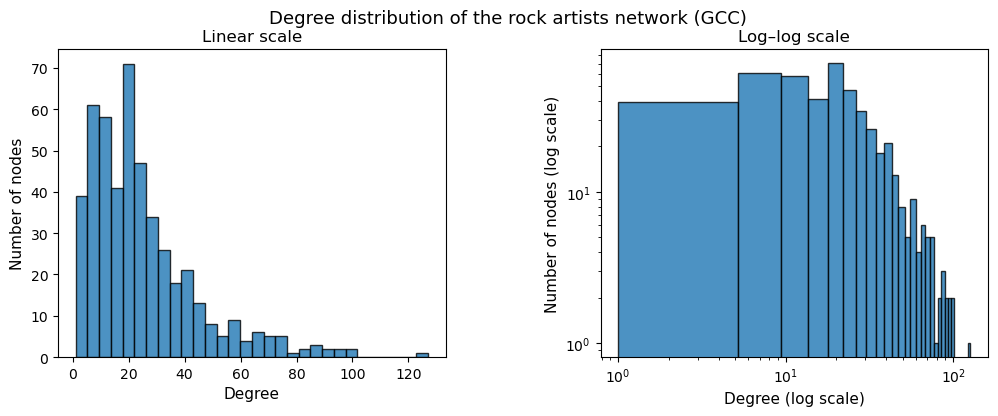

In [4]:
# Compute degrees in the GCC
degrees = dict(G_gcc.degree())
deg_values = np.array(list(degrees.values()))

print(f"Minimum degree: {deg_values.min()}")
print(f"Median degree:  {np.median(deg_values):.1f}")
print(f"Maximum degree: {deg_values.max()}")

fig, (ax1, ax2) = plt.subplots(
    1, 2, figsize=(12, 4),
    gridspec_kw={"wspace": 0.4}
)

fig.suptitle(
    "Degree distribution of the rock artists network (GCC)",
    fontsize=13
)

# Linear-scale degree histogram
ax1.hist(deg_values, bins=30, alpha=0.8, edgecolor="black")
ax1.set_xlabel("Degree", fontsize=11)
ax1.set_ylabel("Number of nodes", fontsize=11)
ax1.set_title("Linear scale", fontsize=12)

# Log–log view to highlight the tail
ax2.hist(deg_values, bins=30, alpha=0.8, edgecolor="black", log=True)
ax2.set_xscale("log")
ax2.set_xlabel("Degree (log scale)", fontsize=11)
ax2.set_ylabel("Number of nodes (log scale)", fontsize=11)
ax2.set_title("Log–log scale", fontsize=12)

# plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()


The degree statistics show that the GCC is fairly heterogeneous: degrees range from **1** to **127**, with a median of **20**. Most artists therefore have a moderate number of connections, but a small subset are connected to an exceptionally large number of others. In the linear-scale histogram, the bulk of nodes lie between roughly 5 and 30 neighbors, while the tail extends toward much higher degrees. The log–log view emphasizes this long right tail, consistent with a **heavy-tailed degree distribution** rather than a narrow, bell-shaped one. This pattern indicates a **core–periphery structure**: a few highly connected hub artists occupy the structural core of the network and provide many of the connections, whereas the majority of artists reside in the periphery with substantially fewer links.


## Centrality: structurally important artists

To identify which artists occupy key positions in the network, two standard centrality measures are considered:

- **Degree centrality**: counts how many neighbors an artist has. This is a local measure of popularity or visibility.
- **Betweenness centrality**: counts how often an artist lies on shortest paths between other artists. This is a global measure of how important a node is for connecting different parts of the network.

The combination of these two measures makes it possible to distinguish between highly connected local hubs and artists that act as bridges between otherwise weakly connected regions of the network.


In [5]:
# Degree centrality 
deg_centrality = nx.degree_centrality(G_gcc)

# Betweenness centrality
bet_centrality = nx.betweenness_centrality(G_gcc, normalized=True)

# Combine into a DataFrame for inspection
cent_df = pd.DataFrame({
    "degree": pd.Series(degrees),
    "degree_centrality": pd.Series(deg_centrality),
    "betweenness_centrality": pd.Series(bet_centrality),
})

# Top 10 artists by degree
top_degree = cent_df.sort_values("degree", ascending=False).head(10)

# Top 10 artists by betweenness
top_betweenness = cent_df.sort_values("betweenness_centrality", ascending=False).head(10)

print("Top 10 artists by degree:")
display(top_degree)

print("Top 10 artists by betweenness centrality:")
display(top_betweenness)


Top 10 artists by degree:


,degree,degree_centrality,betweenness_centrality
Led Zeppelin,127,0.262940,0.046281
Bob Dylan,100,0.207039,0.037563
Queen (band),100,0.207039,0.030879
Metallica,96,0.198758,0.015157
Deep Purple,96,0.198758,0.029351
Black Sabbath,91,0.188406,0.014976
David Bowie,91,0.188406,0.022917
Alice in Chains,89,0.184265,0.021293
Jimi Hendrix,88,0.182195,0.026604
Guns N' Roses,88,0.182195,0.020896


Top 10 artists by betweenness centrality:


,degree,degree_centrality,betweenness_centrality
Led Zeppelin,127,0.262940,0.046281
Bob Dylan,100,0.207039,0.037563
Queen (band),100,0.207039,0.030879
Deep Purple,96,0.198758,0.029351
Jimi Hendrix,88,0.182195,0.026604
Elvis Presley,73,0.151139,0.023658
David Bowie,91,0.188406,0.022917
U2,81,0.167702,0.022557
Alice in Chains,89,0.184265,0.021293
Guns N' Roses,88,0.182195,0.020896


Both rankings are dominated by canonical rock artists. The degree ranking is led by **Led Zeppelin**, **Bob Dylan**, **Queen (band)**, **Metallica**, **Deep Purple**, **Black Sabbath**, and **David Bowie**, all of which have very large local neighborhoods. The betweenness ranking overlaps with this set but also includes artists such as **Elvis Presley** and **U2**, which have slightly lower degree but appear on many shortest paths. These artists therefore play an important **connector role** across stylistic or temporal boundaries, whereas some high-degree artists (for example Metallica or Black Sabbath) are more characteristic of large local hubs whose links are concentrated within dense regions of the network.


### Visualization of centrality structure

To illustrate how centrality is distributed across the network, a ForceAtlas2 layout of the GCC is computed. Node size is proportional to degree, and node color encodes betweenness centrality. This visualization highlights both highly connected hubs and nodes that control many shortest paths through the network.


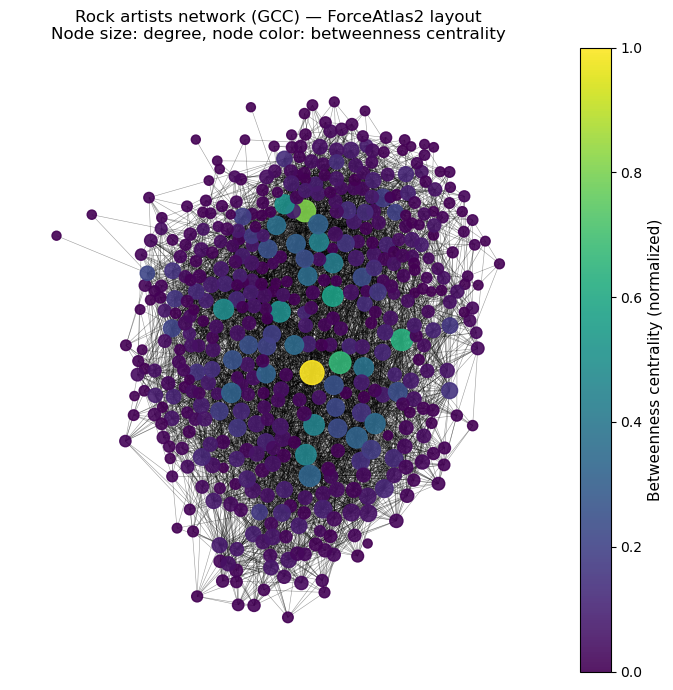

In [6]:
# Ensure compatibility for to_numpy_matrix
if not hasattr(nx, "to_numpy_matrix"):
    def _to_numpy_matrix(G, nodelist=None, dtype=float, weight="weight", nonedge=0.0):
        arr = nx.to_numpy_array(G, nodelist=nodelist, dtype=dtype, weight=weight, nonedge=nonedge)
        try:
            return np.matrix(arr)
        except Exception:
            return arr
    nx.to_numpy_matrix = _to_numpy_matrix

# Prepare data for visualization
deg_array = np.array([degrees[n] for n in G_gcc.nodes()])
bet_array = np.array([bet_centrality[n] for n in G_gcc.nodes()])

# Node sizes (scaled degree)
node_sizes = 40 + 2.0 * deg_array  # base size + scaled degree

# Node colors (betweenness, normalized to [0,1])
if bet_array.max() > 0:
    bet_norm = (bet_array - bet_array.min()) / (bet_array.max() - bet_array.min())
else:
    bet_norm = bet_array

# ForceAtlas2 layout (fa2_modified)
forceatlas2 = ForceAtlas2(
    outboundAttractionDistribution=False,
    linLogMode=False,
    adjustSizes=False,
    edgeWeightInfluence=1.0,
    jitterTolerance=1.0,
    barnesHutOptimize=True,
    barnesHutTheta=1.2,
    scalingRatio=2.0,
    strongGravityMode=False,
    gravity=1.0,
    verbose=False,
)

pos = forceatlas2.forceatlas2_networkx_layout(
    G_gcc,
    pos=None,
    iterations=1000
)

# Plot
fig, ax = plt.subplots(figsize=(7, 7))
nodes = nx.draw_networkx_nodes(
    G_gcc,
    pos,
    node_size=node_sizes,
    node_color=bet_norm,
    cmap=plt.cm.viridis,
    alpha=0.9,
    ax=ax,
)
nx.draw_networkx_edges(G_gcc, pos, width=0.4, alpha=0.4, ax=ax)

cbar = plt.colorbar(nodes, ax=ax)
cbar.set_label("Betweenness centrality (normalized)", fontsize=11)

ax.set_title(
    "Rock artists network (GCC) — ForceAtlas2 layout\n"
    "Node size: degree, node color: betweenness centrality",
    fontsize=12
)
ax.set_axis_off()
plt.tight_layout()
plt.show()


The ForceAtlas2 layout confirms the centrality patterns observed from the numerical measures. A small number of nodes appear both **large** and **bright**, indicating simultaneously high degree and high betweenness centrality. These artists form a dense core through which a large fraction of shortest paths pass. Surrounding this core, many smaller and darker nodes form loosely defined clusters, likely corresponding to subgenres or specific scenes that connect to the rest of the network primarily through the central hubs. Peripheral nodes with few connections tend to lie near the boundary of the layout, emphasizing their structurally marginal position.


##  Relationship between degree and betweenness centrality

Both degree and betweenness centrality identify important artists, but they capture different aspects of importance. To investigate how these measures relate, the two centralities are compared on a node-by-node basis.


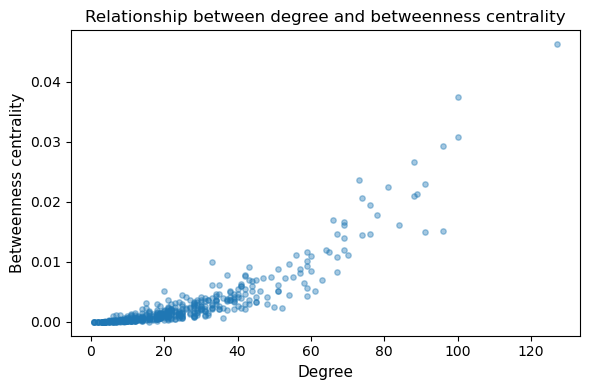

In [7]:
# Scatter plot: degree vs betweenness centrality
fig, ax = plt.subplots(figsize=(6, 4))

ax.scatter(
    cent_df["degree"],
    cent_df["betweenness_centrality"],
    alpha=0.4,
    s=15,
)

ax.set_xlabel("Degree", fontsize=11)
ax.set_ylabel("Betweenness centrality", fontsize=11)
ax.set_title("Relationship between degree and betweenness centrality", fontsize=12)
plt.tight_layout()
plt.show()


The relationship between degree and betweenness centrality is clearly positive: betweenness values increase systematically with degree, and the very highest betweenness scores are attained by the most highly connected artists. This confirms that hubs tend to act as important conduits for shortest paths. At the same time, the scatter is not perfectly tight, particularly at intermediate degrees, where nodes with similar degree can display noticeably different betweenness. This variation reflects different structural roles at comparable connectivity levels, for example, some artists with medium degree connect otherwise weakly linked regions and therefore achieve higher betweenness, while others with similar degree are embedded more locally within a single dense cluster.


## Assortativity and relation to article length

Centrality focuses on individual nodes, while assortativity captures how **similar or dissimilar nodes tend to connect**. Here, degree assortativity is examined to see whether highly connected artists tend to link to other highly connected artists. In addition, the relationship between structural importance (degree) and the external attribute `length_of_content` (Wikipedia article length) is studied to check whether more connected artists also tend to have longer articles.


Degree assortativity coefficient: 0.008
Rows with article length information: 484
Pearson correlation (degree vs. article length):  0.734
Spearman correlation (degree vs. article length): 0.718


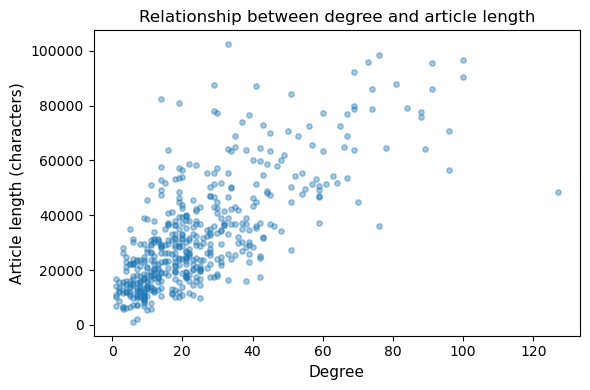

In [8]:
# Degree assortativity
deg_assort = nx.degree_assortativity_coefficient(G_gcc)
print(f"Degree assortativity coefficient: {deg_assort:.3f}")

# Degree vs. article length correlation
length_attr = nx.get_node_attributes(G_gcc, "length_of_content")

# Build dataframe for nodes where the attribute is available
rows = []
for n in G_gcc.nodes():
    if n in length_attr:
        rows.append({
            "artist": n,
            "degree": degrees[n],
            "length_of_content": length_attr[n],
        })

len_df = pd.DataFrame(rows)

print(f"Rows with article length information: {len(len_df)}")

pearson_corr = len_df["degree"].corr(len_df["length_of_content"], method="pearson")
spearman_corr = len_df["degree"].corr(len_df["length_of_content"], method="spearman")

print(f"Pearson correlation (degree vs. article length):  {pearson_corr:.3f}")
print(f"Spearman correlation (degree vs. article length): {spearman_corr:.3f}")

# scatter plot of degree vs. article length
fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(len_df["degree"], len_df["length_of_content"], alpha=0.4, s=15)
ax.set_xlabel("Degree", fontsize=11)
ax.set_ylabel("Article length (characters)", fontsize=11)
ax.set_title("Relationship between degree and article length", fontsize=12)
plt.tight_layout()
plt.show()


The degree assortativity coefficient is approximately **0.008**, which is effectively neutral. This indicates that connections between artists are not strongly structured by degree: highly connected artists link to both high- and low-degree artists without a clear preference. In contrast, the correlations between degree and article length are strongly positive (Pearson ≈ **0.73**, Spearman ≈ **0.72**), and the scatter plot shows a clear upward trend. Artists with higher degree tend to have substantially longer Wikipedia pages, suggesting that structural prominence in the network is closely aligned with how extensively each artist is documented.


## Network backbone: Weighted Network 1 (betweenness-based disparity filter)

The full GCC is dense and visually cluttered, which makes it difficult to see large-scale structure. To extract a clearer structural “skeleton”, a backbone is constructed using the **disparity filter** introduced by Serrano et al. (PNAS 2009). 

First, each edge is assigned a weight proportional to its **edge betweenness centrality** (fraction of shortest paths that use the edge), rescaled to the interval \([1, 100]\). The disparity filter then tests, for each node, whether the weight of an incident edge is significantly larger than expected under a random allocation of weights. An undirected edge is kept in the backbone if it is significant for at least one of its endpoints. This emphasizes edges that are important for connecting different parts of the network.


In [9]:
# Helper: rescale values to [a, b]
def minmax_scale(vals, a=1.0, b=100.0):
    arr = np.asarray(list(vals), dtype=float)
    vmin, vmax = arr.min(), arr.max()
    if np.isclose(vmin, vmax):
        return np.full_like(arr, (a + b) / 2.0)
    return (arr - vmin) / (vmax - vmin) * (b - a) + a

# Edge betweenness centrality and weighted network W1
ebc = nx.edge_betweenness_centrality(G_gcc, normalized=True)
scaled_weights = minmax_scale(ebc.values(), a=1.0, b=100.0)

G_w1 = G_gcc.copy()
for (edge, w) in zip(ebc.keys(), scaled_weights):
    u, v = edge
    G_w1[u][v]["weight"] = float(w)

print("[W1] Weighted network constructed from edge betweenness.")


[W1] Weighted network constructed from edge betweenness.


In [10]:
# Disparity filter implementation (undirected version)
def disparity_backbone(Gw, alpha=0.20, mode="or"):
    """
    Undirected disparity filter backbone.
    Gw: weighted undirected graph with edge attribute 'weight'.
    alpha: significance level.
    mode: 'or' keeps edge if significant at either endpoint; 'and' requires both.
    """
    assert not Gw.is_directed()
    B = nx.Graph()
    B.add_nodes_from(Gw.nodes(data=True))

    # Degree and node strength
    deg = dict(Gw.degree())
    strength = {n: 0.0 for n in Gw.nodes()}
    for u, v, d in Gw.edges(data=True):
        w = float(d.get("weight", 1.0))
        strength[u] += w
        strength[v] += w

    def significant(p, k):
        if k <= 1:
            return True
        # Tail probability (Serrano et al. 2009)
        return (1.0 - p) ** (k - 1) < alpha

    for u, v, d in Gw.edges(data=True):
        w = float(d.get("weight", 1.0))
        pu = w / strength[u] if strength[u] > 0 else 0.0
        pv = w / strength[v] if strength[v] > 0 else 0.0
        keep_u = significant(pu, deg[u])
        keep_v = significant(pv, deg[v])
        keep = (keep_u or keep_v) if mode == "or" else (keep_u and keep_v)
        if keep:
            B.add_edge(u, v, **d)

    return B

# Build backbone B1 from W1
alpha_w1 = 0.20
B1 = disparity_backbone(G_w1, alpha=alpha_w1, mode="or")

edges_full = G_gcc.number_of_edges()
edges_b1 = B1.number_of_edges()
frac_kept_b1 = edges_b1 / edges_full

components_b1 = nx.number_connected_components(B1)
print(f"[B1] Backbone edges: {edges_b1} / {edges_full} ({frac_kept_b1:.1%} kept)")
print(f"[B1] Number of connected components: {components_b1}")


[B1] Backbone edges: 1120 / 6023 (18.6% kept)
[B1] Number of connected components: 3


[B1] Backbone GCC for plotting: 482 nodes, 1120 edges


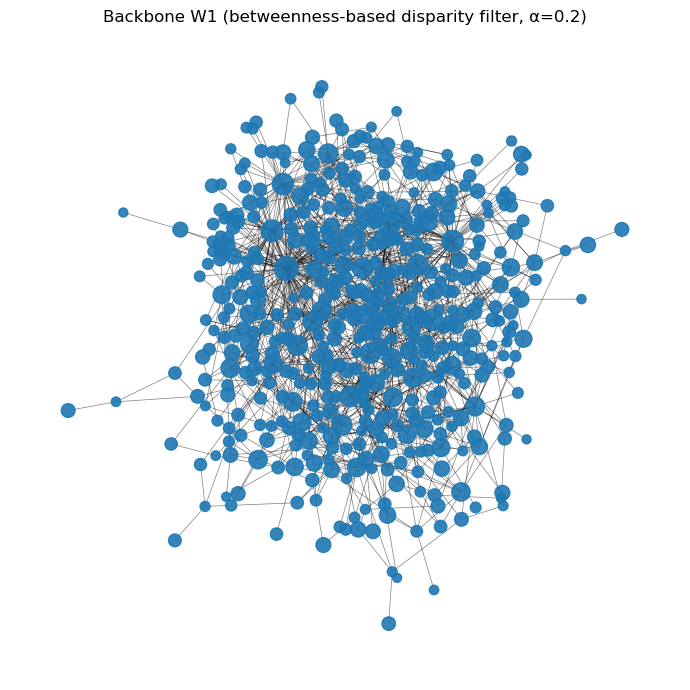

In [11]:
# Visualization of the W1 backbone (GCC only)

# Work on a copy for plotting and drop isolates to simplify the layout
H = B1.copy()
isolates = list(nx.isolates(H))
H.remove_nodes_from(isolates)

# Keep only the largest component of the backbone for visualization
if H.number_of_nodes() > 0:
    gcc_nodes_b1 = max(nx.connected_components(H), key=len)
    H_gcc = H.subgraph(gcc_nodes_b1).copy()
else:
    H_gcc = H

print(f"[B1] Backbone GCC for plotting: {H_gcc.number_of_nodes()} nodes, {H_gcc.number_of_edges()} edges")

# Node sizes based on original degree in G_gcc
sizes_b1 = 40 + 2.0 * np.array([degrees[n] for n in H_gcc.nodes()])

# ForceAtlas2 layout on the backbone (fa2_modified)
forceatlas2_b1 = ForceAtlas2(
    outboundAttractionDistribution=False,
    linLogMode=False,
    adjustSizes=False,
    edgeWeightInfluence=1.0,
    jitterTolerance=1.0,
    barnesHutOptimize=True,
    barnesHutTheta=1.2,
    scalingRatio=2.0,
    strongGravityMode=False,
    gravity=1.0,
    verbose=False,
)

pos_b1 = forceatlas2_b1.forceatlas2_networkx_layout(
    H_gcc,
    pos=None,
    iterations=1000
)

fig, ax = plt.subplots(figsize=(7, 7))
nx.draw_networkx_edges(H_gcc, pos_b1, width=0.5, alpha=0.5, ax=ax)
nx.draw_networkx_nodes(H_gcc, pos_b1, node_size=sizes_b1, alpha=0.9, ax=ax)

ax.set_title(
    f"Backbone W1 (betweenness-based disparity filter, α={alpha_w1})",
    fontsize=12
)
ax.set_axis_off()
plt.tight_layout()
plt.show()


The disparity-based backbone retains **1120** of the original **6023** edges (approximately **18.6%**) while preserving almost all nodes in a single giant component (482 nodes in the plotted GCC and only three components in total). The visualization shows that, even after substantial pruning, the network remains densely interconnected around a core of highly connected artists. Peripheral nodes are typically linked to this core via a small number of edges, while many weak local links present in the full graph have been removed. This indicates that a relatively small subset of edges, those with high edge betweenness and local weight significance, carry much of the global connectivity structure of the rock artist network.


## Centrality in the full network vs. the backbone

The disparity backbone removes many weaker edges while preserving the most structurally important connections. To understand how this pruning affects individual artists, degree centrality in the full GCC is compared with degree in the W1 backbone. This comparison reveals which artists remain central after pruning and which artists lose most of their connections once only significant edges are retained.


Pearson correlation (degree_full vs degree_backbone):  0.705
Spearman correlation (degree_full vs degree_backbone): 0.533


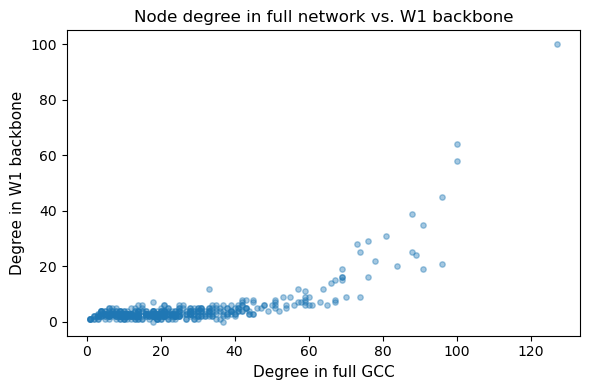

Top 10 artists by degree in the full GCC and their backbone degrees:


,degree_full,degree_backbone
artist,,
Led Zeppelin,127,100
Bob Dylan,100,64
Queen (band),100,58
Metallica,96,21
Deep Purple,96,45
Black Sabbath,91,19
David Bowie,91,35
Alice in Chains,89,24
Jimi Hendrix,88,39


In [12]:
# Degree in the full GCC
deg_full = dict(G_gcc.degree())

# Degree in the backbone B1
deg_backbone = dict(B1.degree())

# Build a DataFrame with one row per node in the GCC
rows = []
for n in G_gcc.nodes():
    rows.append({
        "artist": n,
        "degree_full": deg_full.get(n, 0),
        "degree_backbone": deg_backbone.get(n, 0),
    })

deg_back_df = pd.DataFrame(rows)

# Compute correlations between full and backbone degrees
pearson_deg = deg_back_df["degree_full"].corr(deg_back_df["degree_backbone"], method="pearson")
spearman_deg = deg_back_df["degree_full"].corr(deg_back_df["degree_backbone"], method="spearman")

print(f"Pearson correlation (degree_full vs degree_backbone):  {pearson_deg:.3f}")
print(f"Spearman correlation (degree_full vs degree_backbone): {spearman_deg:.3f}")

# Scatter plot: degree in full network vs degree in backbone
fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(
    deg_back_df["degree_full"],
    deg_back_df["degree_backbone"],
    alpha=0.4,
    s=15,
)

ax.set_xlabel("Degree in full GCC", fontsize=11)
ax.set_ylabel("Degree in W1 backbone", fontsize=11)
ax.set_title("Node degree in full network vs. W1 backbone", fontsize=12)
plt.tight_layout()
plt.show()

# Inspect a few top artists in both views
top_artists_compare = (
    deg_back_df
    .sort_values("degree_full", ascending=False)
    .head(10)
    .set_index("artist")[["degree_full", "degree_backbone"]]
)
print("Top 10 artists by degree in the full GCC and their backbone degrees:")
display(top_artists_compare)


The comparison between degrees in the full GCC and in the W1 backbone shows a clear, but not perfect, positive relationship. The Pearson correlation of **0.705** and Spearman correlation of **0.533** indicate that artists who are highly connected in the full network generally retain higher degree after backbone extraction, although ranks are not preserved exactly. The scatter plot illustrates this trend: most points follow an increasing pattern, with a small number of extreme hubs standing out. The table for the top-degree artists makes the effect more concrete. **Led Zeppelin**, **Bob Dylan**, and **Queen (band)** retain very high degrees in the backbone (100, 64, and 58, respectively), which means that most of their connections are considered structurally significant by the disparity filter. In contrast, artists such as **Metallica** and **Black Sabbath** lose a larger fraction of their links (96→21 and 91→19), suggesting that many of their ties are more locally redundant or less critical for global connectivity. Overall, the backbone preserves the central roles of the main hubs while selectively pruning a substantial number of weaker connections around them.


## Overall interpretation of the rock artists network

- The rock artists network appears as a **dense, hub-dominated system** with a clear core–periphery organization. The degree distribution is heavy-tailed: degrees span from 1 to 127 with a median around 20, so most artists have a moderate number of neighbors while a small set of hubs accumulate many links. This implies that connectivity is strongly concentrated around a limited group of key artists. 

- Centrality provides a clearer picture. Classical acts such as **Led Zeppelin**, **Bob Dylan**, **Queen (band)**, and **Deep Purple** rank at the top of both degree and betweenness centrality and occupy the bright, central region of the ForceAtlas2 layout. The degree–betweenness scatter plot shows a strong positive trend, but also some spread at intermediate degrees, indicating different structural roles: some artists act as **brokers** connecting several regions of the graph, while others with similar degree function mainly as **local hubs** inside a single dense community. 

- Assortativity and attribute analyses link structure to external information. Degree assortativity is essentially neutral, suggesting that high- and low-degree artists mix relatively freely rather than forming separated “elite” and “peripheral” layers. In contrast, degree correlates strongly with Wikipedia article length, and the scatter plot shows a clear upward trend. Structurally central artists therefore tend to be more extensively documented, which matches expectations for historically influential bands. 

- The betweenness-based disparity backbone offers a complementary view by focusing on **structurally significant edges**. The disparity filter (Serrano et al., 2009) retains only about 19% of the edges while leaving almost all nodes in a connected giant component. The comparison between degrees in the full network and in the backbone shows substantial, but not perfect, correlation: hubs such as Led Zeppelin, Bob Dylan, and Queen (band) remain highly connected after pruning, whereas other high-degree artists lose a larger fraction of their links. This indicates that the backbone preserves the core structural roles while filtering out many weaker or locally redundant ties. Overall, standard tools reveal a network in which a small, densely interconnected core of iconic artists organizes connectivity across a large and diverse periphery.


# Part 2: Genres, Communities, and Plotting

For this part, we will explore the modularity measure $M$. We will do a deep dive into the network of rock performers and explore the communities of genres present in it.


## Part 2.1: Modularity and Genres

### Modularity Explained

As a point of departure, we will briefly describe the modularity measure in the context of networks.

**Modularity** $M$ is a measure of the quality of partitions in a graph or network. It measures how well a network is divided into groups (communities) compared to what would be expected by _random chance_. The higher $M$ is for a given partition, the better the community structure at hand is. This means that the nodes in that community have more edges between them than would be expected in a random network with the same degree distribution. At $M=0$, the network’s edges are distributed randomly with no group structure. In this case, we assign all nodes to the same community.

Modularity $M$ allows us to decide whether one community partition is better than another. It can help us predict which of the partitions predicted by a hierarchical method offer the best community structure (i.e., the partition that maximizes $M$).

We compute modularity $M$ as it's described in the Network Science textbook ([Chapter 9, Section 9.4](https://networksciencebook.com/chapter/9#modularity)). The formula from the book is shown below:

$$
M = \sum_{c=1}^{n_c} \left[ \frac{L_c}{L} - \left( \frac{k_c}{2L} \right)^2 \right]
$$

Where:

$$
\begin{align*}
L_c &: \text{Number of links within a community $c$} \\
L &: \text{Total number of links in the network} \\
k_c &: \text{Sum of degrees of nodes within a community $c$} \\
n_c &: \text{Number of communities}
\end{align*}
$$

### Goal and Objectives

Our goal is to examine community alignment with the music genres in our network of rock performers. To this end, we will explore the following:

- Calculate the genre-based modularity
- Detect communities using the Louvain method and calculate their modularity
- Compare the genre-based communities with the ones identified by the Louvain algorithm
- Generate the confusion matrix for the genres and communities
- Visualize the network with communities


### Part 2.2: Calculation of Modularity, Community Detection, and Comparison


We begin our analysis by loading our network.


In [2]:
url = "https://raw.githubusercontent.com/adamajane/social-graphs-and-interactions-02805-assignments/refs/heads/main/assignment_2/files/artists_graph_with_stats.gexf"

# Fetch file from GitHub
response = requests.get(url)
response.raise_for_status()

# Load into NetworkX
G = nx.read_gexf(BytesIO(response.content))
G = G.to_undirected()
print(
    f"Network successfully loaded: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges"
)

Network successfully loaded: 484 nodes, 6025 edges


#### Modularity Calculation

Below, we define a function that calculates modularity based on equation 9.12 in [Network Science, Chapter 9, Section 9.4](https://networksciencebook.com/chapter/9#modularity)


In [3]:
def calculate_modularity(G, communities):
    # Total number of edges in the network
    L = G.number_of_edges()
    M = 0.0

    if L == 0:
        raise ValueError("Graph has no edges")

    # Group nodes by community
    community_nodes = {}
    for node, comm in communities.items():
        community_nodes.setdefault(comm, set()).add(node)

    for c, nodes in community_nodes.items():
        # Subgraph of the current community
        subgraph = G.subgraph(nodes)

        # L_c = number of edges within this community
        L_c = subgraph.number_of_edges()

        # k_c = sum of degrees of nodes within the community
        k_c = sum(dict(G.degree(nodes)).values())

        # Add term for this community
        M += (L_c / L) - (k_c / (2 * L)) ** 2

    return M

Before we dive into the calculation of the genre-based modularity of our rock performer network, we want to note that the vast majority of the artists have `rock` listed as their primary musical genre. Therefore, if the `rock` genre is a large community, the network won't have that high a modularity. This is an important point to bear in mind for this section.

Nevertheless, let's start by computing the modularity of the network across all genres included to explore whether the musical styles naturally cluster into clear communities.


In [5]:
# Load genre data from JSON
with open("artist_genres.json", "r") as f:
    genre_data = json.load(f)

# Create a mapping from artist (node) to its primary genre
genre_map = {}
for artist in G.nodes():
    if artist in genre_data and len(genre_data[artist]) > 0:
        # Take the first listed genre as the representative one
        genre_map[artist] = genre_data[artist][0].lower()
    else:
        # If no genre data is found, assign "unknown"
        genre_map[artist] = "unknown"

# Calculate modularity using the genre-based partition
M_genre = calculate_modularity(G, genre_map)

print(f"Genre-based modularity (using first genre): {M_genre:.4f}")

Genre-based modularity (using first genre): 0.0970


When we include `rock` as a genre, we get a modularity of $M=0.0970$. This low value implies that the artists' genre connections do not form tightly separated genre-based groups. Including the `rock` label basically "swallows" most nodes, creating one giant, dense group in the process. This makes it difficult for the modularity measure to detect any meaningful structure in the network. Essentially, the network looks too homogenous as most edges are within the `rock` genre. Since `rock` is most of the graph, this doesn’t stand out compared to random chance. That is, the network appears almost random w.r.t. those genres.

In the hope of achieving a higher modularity score, we will now tweak the dataset by picking the first non-`rock` music genre for the performers with more than one genre listed. Below, we have adjusted the code to do just that.


In [6]:
# Load genre data from JSON
with open("artist_genres.json", "r") as f:
    genre_data = json.load(f)

# Assign first non-rock genre if possible
genre_map_nonrock = {}
for artist in G.nodes():
    genres = [g.lower() for g in genre_data.get(artist, [])]

    if not genres:
        genre_map_nonrock[artist] = "unknown"
        continue

    # Try to find the first genre that's not 'rock'
    non_rock_genres = [g for g in genres if g != "rock"]

    if non_rock_genres:
        genre_map_nonrock[artist] = non_rock_genres[0]
    else:
        # If all genres are 'rock', fall back to 'rock'
        genre_map_nonrock[artist] = "rock"

# Calculate modularity using this adjusted mapping
M_nonrock = calculate_modularity(G, genre_map_nonrock)

print(f"Genre-based modularity (first non-rock genre): {M_nonrock:.4f}")

Genre-based modularity (first non-rock genre): 0.1481


As we can see, the modularity acutally increases to $M = 0.1481$. This means that the heavy presence of the `rock` genre was indeed concealing insightful community structure in the network. By introducing clearer categorical distinctions, the network separates into smaller and more cohesive clusters that better reflect the genre-based communities. However, the increase is not significant, which still indicates that music genres provides a limited insight into the underlying communities in the network. That is, the genre explains _part_ of how the performers are connected, but it does not fuully account for the network's shape.

To further explore how these communities emerge and to quantify their cohesion, we can apply a community detection algorithm. To this end, we will ues the **Louvain** method, which optimizes modularity to uncover dense clusters within the network.


#### The Louvain Method for Community Detection


The Louvain algorithm detects communities in the network by maximizing the modularity measure. This approach differs from our previous genre-based one by examining the network's connections. Let's take a look.


In [7]:
# Detect communities using the Louvain method
louvain_comms = nx.community.louvain_communities(G, seed=42)
print(f"Detected {len(louvain_comms)} communities using Louvain method")

# Create a mapping from node to community label
louvain_map = {}
for i, comm in enumerate(louvain_comms):
    for node in comm:
        louvain_map[node] = i

# Calculate modularity for Louvain partition
M_louvain = calculate_modularity(G, louvain_map)

print(f"Louvain modularity: {M_louvain:.4f}")

Detected 4 communities using Louvain method
Louvain modularity: 0.3394


With the Louvain method, we get a modularity of $M = 0.3394$, which is noticably higher than the genre-based approach and near a value of an optimal partition. This implies that our graph has a stronger intrinsic community structure than what the genres alone explain. Put another way, this means that the artists' connections do not perfectly align with their listed music genres and that there are cross-genre clusters that the Louvain algorithm detects.

#### Partial Conclusion

Genres give a partial lens into the community structure, but they don’t fully align with the intrinsic clusters that arise from actual artist relationships. The network’s modularity is significantly stronger when communities are detected using the Louvain method, which suggests the rock performers are interconnected across subgenres more than its genre data would imply.

Now that we know how these partitions differ, we can visualize their relationship through a **confusion matrix** by comparing Louvain communities (rows) to genre labels (columns). This will tell us which genres dominate each community and whether certain genres cluster together.

### Part 2.3: Confusion Matrix comparing Communities vs. Genres

We start by calculating the confusion matrix $D$. It's done below.


Top 7 genres: ['rock', 'pop', 'metal', 'post-grunge', 'new wave', 'country', 'folk']
Top 7 communities: [2, 0, 3, 1]

Confusion matrix D (Top 7 genres × Top 7 communities):
               2    0   3   1
rock         178  150  86  44
pop           60   61   8   3
metal          2   23  72  29
post-grunge    0    9   2  32
new wave       8   22   1   0
country       15    3   4   0
folk          13    5   1   1

Normalized confusion matrix (row-wise proportions):
                    2         0         3         1
rock         0.388646  0.327511  0.187773  0.096070
pop          0.454545  0.462121  0.060606  0.022727
metal        0.015873  0.182540  0.571429  0.230159
post-grunge  0.000000  0.209302  0.046512  0.744186
new wave     0.258065  0.709677  0.032258  0.000000
country      0.681818  0.136364  0.181818  0.000000
folk         0.650000  0.250000  0.050000  0.050000


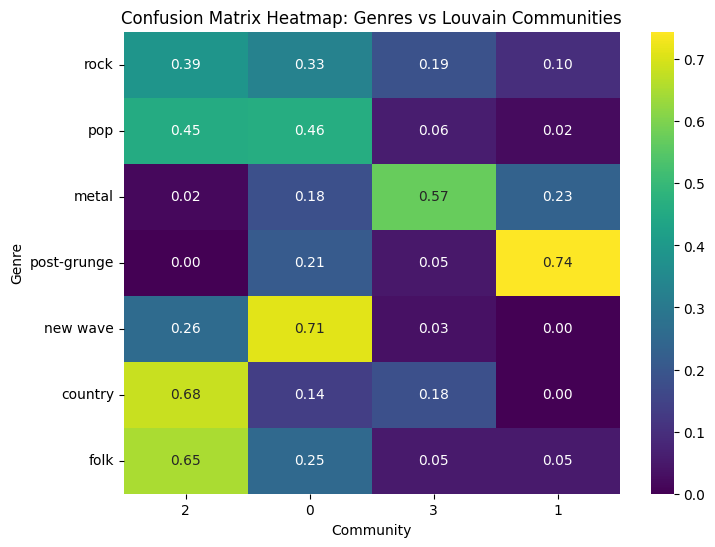

In [8]:
# Identify top 7 genres
all_genres_flat = [g.lower() for genres in genre_data.values() for g in genres]
top7_genres = [g for g, _ in Counter(all_genres_flat).most_common(7)]
print("Top 7 genres:", top7_genres)

# Identify top 7 communities (by size)
comm_sizes = [(i, len(c)) for i, c in enumerate(louvain_comms)]
comm_sizes.sort(key=lambda x: x[1], reverse=True)
top7_comms = [i for i, _ in comm_sizes[:7]]
print("Top 7 communities:", top7_comms)

# Initialize empty matrix (genre × community)
D = pd.DataFrame(0, index=top7_genres, columns=top7_comms)

# Fill matrix based on overlapping membership
for node in G.nodes():
    # Skip nodes not in top 7 communities
    comm = louvain_map.get(node)
    if comm not in top7_comms:
        continue

    # Get node's genres (lowercase)
    node_genres = [g.lower() for g in genre_data.get(node, [])]

    # For each genre that’s one of the top 7, increment the appropriate cell
    for g in node_genres:
        if g in top7_genres:
            D.loc[g, comm] += 1

# Print confusion matrix
print("\nConfusion matrix D (Top 7 genres \u00d7 Top 7 communities):")
print(D)

# Normalize by genre (row-wise proportions)
D_normalized = D.div(D.sum(axis=1), axis=0)
print("\nNormalized confusion matrix (row-wise proportions):")
print(D_normalized)

# Confusion matrix heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(D_normalized, annot=True, cmap="viridis", fmt=".2f")
plt.xlabel("Community")
plt.ylabel("Genre")
plt.title("Confusion Matrix Heatmap: Genres vs Louvain Communities")
plt.show()

#### Partial Conclusion

From our confusion matrices, we observe that the communities detected by the Louvain algorithm only partially align with musical genres. For instance, `rock` artists are spread across multiple communities (mostly 2 and 0). This suggests that the `rock` genre is too broad to capture distinct network structures, which could reflect stylistic diversity within the genre. In contrast, `post-grunge` and `metal` show stronger alignment, with clear concentration in one or two communities. These may indicate more tightly connected sub-scenes of performers. Genres like `pop` and `new wave` overlap heavily with other genres’ communities, which could imply cross-genre collaborations or blending of styles.

Overall, while some communities correspond well to specific genres, others likely capture higher-level structures such as influences, collaborations, or time period clusters rather than genre boundaries alone.

### Part 2.4: Community Plotting and Visualization

Plot the communities and comment on your results.


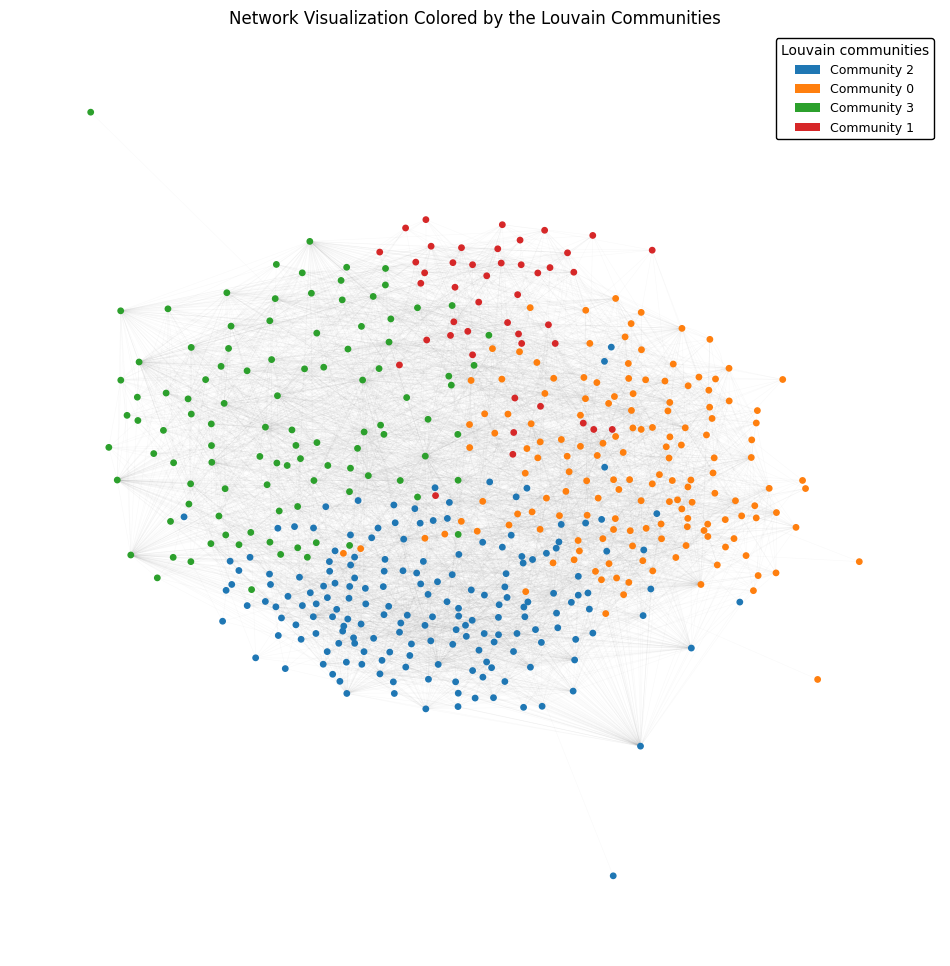

In [9]:
# ForcAtlas2 layout
forceatlas2 = ForceAtlas2(
    outboundAttractionDistribution=True,
    linLogMode=False,
    adjustSizes=False,
    edgeWeightInfluence=1.0,
    jitterTolerance=1.0,
    barnesHutOptimize=True,
    barnesHutTheta=1.2,
    scalingRatio=10.0,
    gravity=1.0,
    verbose=False,
)

# Compute ForceAtlas2 positions
pos = forceatlas2.forceatlas2_networkx_layout(G, pos=None, iterations=500)

# Color palette for the largest communities
top_n = 8
comm_sizes = sorted(
    ((idx, len(nodes)) for idx, nodes in enumerate(louvain_comms)),
    key=lambda x: x[1],
    reverse=True,
)
top_comm_ids = [comm for comm, _ in comm_sizes[:top_n]]
palette = sns.color_palette("tab10", n_colors=len(top_comm_ids))
community_palette = {comm: palette[i] for i, comm in enumerate(top_comm_ids)}
default_color = (0.85, 0.85, 0.85)

node_colors = [
    community_palette.get(louvain_map[node], default_color) for node in G.nodes()
]

plt.figure(figsize=(12, 12))
nx.draw_networkx_edges(G, pos, alpha=0.05, width=0.4, edge_color="gray")
nx.draw_networkx_nodes(G, pos, node_size=15, node_color=node_colors)

legend_handles = [
    Patch(
        facecolor=community_palette[comm],
        edgecolor="none",
        label=f"Community {comm}",
    )
    for comm in top_comm_ids
]

plt.legend(
    handles=legend_handles,
    loc="upper right",
    frameon=True,
    fancybox=True,
    framealpha=1.0,
    edgecolor="black",
    fontsize=9,
    title="Louvain communities",
)

plt.title("Network Visualization Colored by the Louvain Communities")
plt.axis("off")
plt.show()

#### Observations

In the above network, we observe the distinct clusters computed using the Louvain method. Each color represents a structural community, and we can clearly see several dense clusters with relatively few edges connecting them. This pattern indicates that artists within the same community are more closely linked while inter-community connections are sparser. The boundaries between the clusters aren’t perfectly sharp, which reflects the real-world overlap between musical genres and influences in rock music.

Overall, the visualization supports the modularity results, showing that the Louvain method captures an insightful community structure within the network.


# Part 3: TF-IDF to Understand Genres and Communities


## Part 3.1: TF-IDF Explained

**TF-IDF** (**T**erm **F**requency-**I**nverse **D**ocument **F**requency) measures the importance of a word within a document compared to its importance across all documents in a corpus. This is an interesting measure as it highlights the terms unique to a collection of text, which assists in identifying characteristic language of genres and communities. **TF** is a measure for a single term in a document. **IDF** measures it's relative rarity across the corpus.

TF-IDF is calculated using the formula: $$\text{TF-IDF}(t, d) = \text{TF}(t, d) \times \text{IDF}(t)$$

Where:

$$
\text{TF}(t, d) = \frac{\text{Number of times term } t \text{ appears in document } d}{\text{Total number of terms in } d} = \frac{f_{t,d}}{\sum_{t' \in d} f_{t',d}} \\[6pt]
\text{IDF}(t) = \log\left( \frac{N}{\text{n}_{t}} \right) \\[6pt]
$$

TF-IDF is useful for identifying unique keywords, comparing text similarity, and clustering or classifying documents based on their language patterns. In relation to genres and communities, it can help uncover distinctive language usage and reveal thematic differences across musical styles.


# Part 4: Sentiment of Artists and Communities


_Code and text here_
